In [2]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
L=100

def states(tau, L=L):
    t = np.linspace(-9*tau, 1*tau, 200)
    return Parallel(n_jobs=-1)(
        delayed(state)(L, tau, ti) for ti in t
    )
def defects_x(states):
    z = []
    for state in states:
        z.append(1-sigmax([0,1],state))
    return array(z)

def defects_z(states):
    z = []
    for state in states:
        z.append(sigmaz([0],state))
    return array(z)

t = np.linspace(-9, 1, 200)

t1= 1
t2 = 10
t3 = 100
states_t1= states(t1)
states_t2= states(t2)
states_t3= states(t3)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


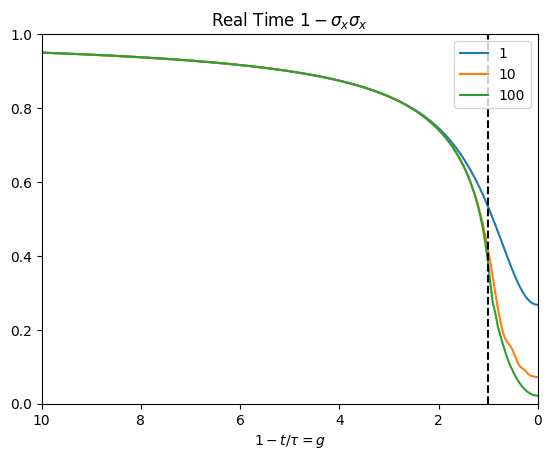

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


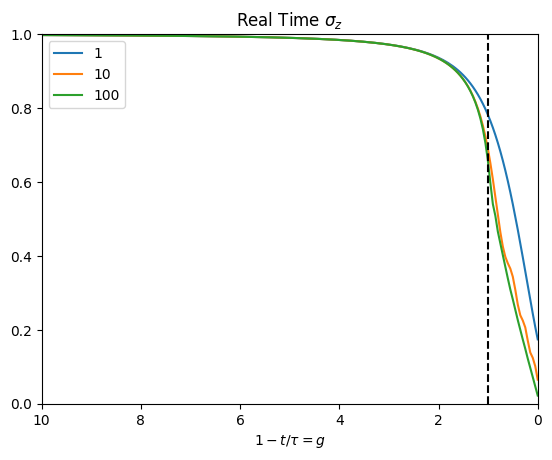

In [3]:
plot(1-t,defects_x(states_t1),label=t1)
plot(1-t,defects_x(states_t2),label=t2)
plot(1-t,defects_x(states_t3),label=t3)
title(r"Real Time $1-\sigma_x \sigma_x$")
xlim(10,0)
xlabel(r"$1-t/\tau=g$")
plt.vlines(1,0,1,ls="--",color="black")
ylim(0,1)
legend()
show()
plot(1-t,defects_z(states_t1),label=t1)
plot(1-t,defects_z(states_t2),label=t2)
plot(1-t,defects_z(states_t3),label=t3)
title(r"Real Time $\sigma_z$")
xlabel(r"$1-t/\tau=g$")
ylim(0,1)
plt.vlines(1,0,1,ls="--",color="black")

xlim(10,0)

legend()
show()

# Quench Velocities

In [4]:
taus = np.logspace(-2,3,100)
v = 1/taus
L = 500
def states(taus, L=L):
    return Parallel(n_jobs=-1)(
        delayed(state)(L, tau, tau) for tau in taus
    )

states_taus = states(taus)


NameError: name 'f' is not defined

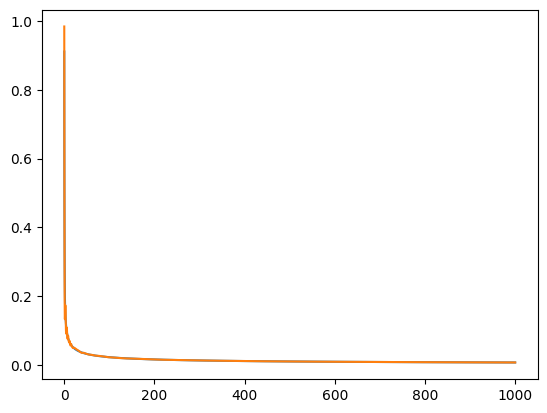

In [5]:
plot(taus,defects_x(states_taus),label=r"$xx$ defect")
plot(taus,defects_z(states_taus),label=r"$z$ defect")


plot(taus, 1-f(1,taus),"--k",label="Ansatz x 2")
loglog()
legend()

ylim(0,1)
plt.xlabel(r"$\tau$")

In [ ]:
def Cxx(states_taus,r):
    dat =[]
    for state in tqdm(states_taus):
        Cxx=  array([sigmax([0,ri],state) for ri in r])
        dat.append(Cxx)
    return dat

In [ ]:
r = np.arange(1,50)
x = Cxx(states_taus,r)

In [ ]:
def ansatz(r,tau):
    return exp(-0.174*r/sqrt(tau))*cos( sqrt(log(2)/(2*pi*tau))*r)

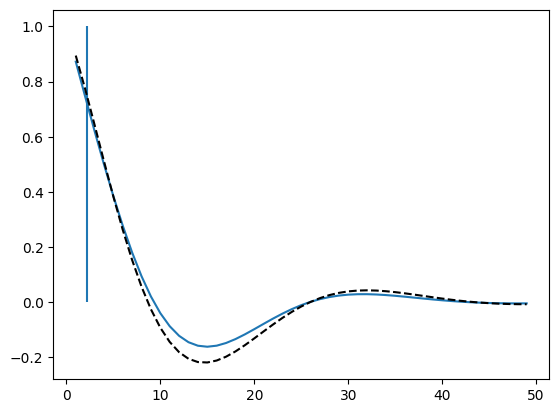

In [ ]:
i = 50
tau = taus[i]
dat = x[i]
l = sqrt(tau)*log(tau)
plt.vlines(l,0,1)
plot(r,dat,label=tau)
plot(r,ansatz(r,tau),"--k")
#legend()

In [6]:
from itertools import combinations
from collections import Counter
def BA(r, taus):
    v= 1/taus
    term1 = -(np.sqrt(v) / (np.sqrt(2) * np.pi))
    
    term2 = (r**2 * v**1.5) / (8 * np.sqrt(2) * np.pi**2)
    
    exp1 = np.exp((2j)/v - (r**2 * v * (np.pi - 1j*np.log(v))) / (4 * np.log(v)**2))
    exp2 = np.exp(-(2j)/v - (r**2 * v * (np.pi + 1j*np.log(v))) / (4 * np.log(v)**2))
    
    term3 = ( (exp1 + exp2) * v**1.5 * np.abs(r) * np.sign(r) ) / \
            (4 * np.abs(np.log(v)) * np.log(v))
    
    term4 = 0.5 * (
        2 * (1 if r == 0 else 0)
        - 2 * (1 if abs(r) == 0 else 0)
        + (1 if abs(r) == 1 else 0)
        + (1 if abs(r) == 1 else 0) * np.sign(r)
    )
    
    return term1 + term2 + term3 + term4

def D(n,taus):
    """Strange Convention, n = r-1"""
    r = n+1
    return BA(r,taus)

def sigma_general(indices,tau):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,tau)
    return np.linalg.det(C)


################################################
#           PPROJECTORS
################################################
def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,taus, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,taus)*degen)
    #Manually add the 1 
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

In [7]:


exact = array([ Px(10,state) for state in tqdm(states_taus)])
# plot(taus,exact,label=r"$xx$ defect")
# plot(taus,x)
# loglog()

100%|██████████| 100/100 [00:07<00:00, 13.35it/s]


In [8]:
from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm

ns = np.arange(2, 15)

def compute_row(n):
    return np.array([P_n(n, tau) for tau in taus])

# Run in parallel over n
x = Parallel(n_jobs=-1)(
        delayed(compute_row)(n) 
        for n in tqdm(ns)
    )


100%|██████████| 13/13 [00:00<00:00, 13713.77it/s]


In [9]:
from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm

ns = np.arange(2, 15)

def compute_row(n):
    return np.array([Px(n, state) for state in states_taus])

# Run in parallel over n
Y = Parallel(n_jobs=-1)(
        delayed(compute_row)(n) 
        for n in tqdm(ns)
    )

100%|██████████| 13/13 [00:00<00:00, 12985.46it/s]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_3544/3778105519.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,1)


Text(0.5, 1.0, 'Exact (dashed) and large tau expansion (color) projectors')

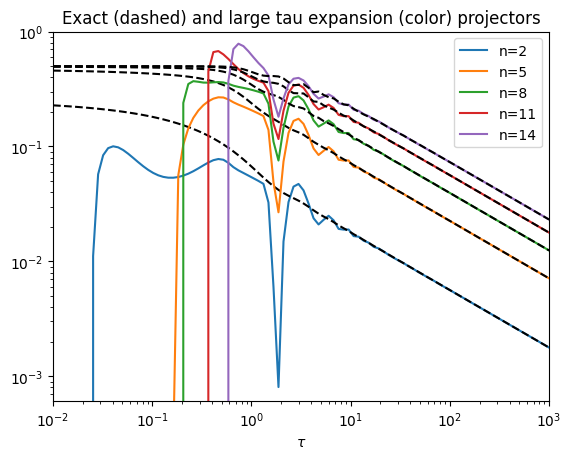

In [10]:
for i, n in enumerate(ns):
    if i%3==0:
        plot(taus,1/2-x[i],label=f"n={n}")
        plot(taus,1/2-Y[i],"--k")
        loglog()
        xlabel(r"$\tau$")
        ylim(0,1)
        xlim(taus[0],taus[-1])
        #show()
legend()
title("Exact (dashed) and large tau expansion (color) projectors")


Text(0.5, 1.0, 'Absolute value of Exact-Large Tau Expansion')

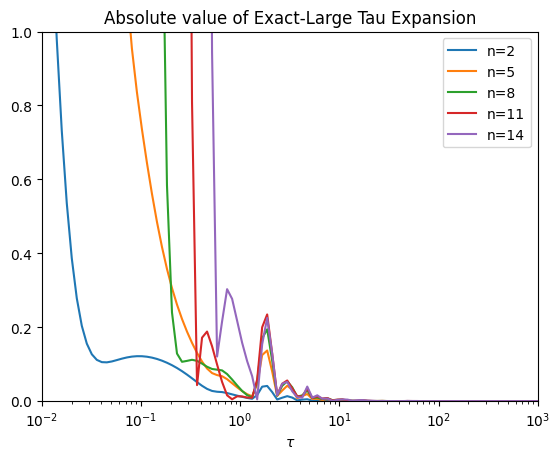

In [11]:
for i, n in enumerate(ns):
    if i%3==0:
        plot(taus,abs((1/2-Y[i])-(1/2-x[i])),label=f"n={n}")
        xscale("log")
        xlabel(r"$\tau$")
        ylim(0,1)
        xlim(taus[0],taus[-1])
        #show()
legend()
title(r"Absolute value of Exact-Large Tau Expansion")


In [12]:
dat=[]
for i, n in enumerate(ns):
    if i % 1 == 0:
        f = np.abs((1/2 - Y[i]) - (1/2 - x[i]))   # your plotted quantity
        above = np.where(f < 1)[0]

        if len(above) == 0:
            print(f"n = {n}: never exceeds 1")
        else:
            k = above[0]              # first index where f > 1
            print(f"n = {n}: exceeds 1 at tau = {taus[k]}, index {k}")
            dat.append(taus[k])


n = 2: exceeds 1 at tau = 0.014174741629268055, index 3
n = 3: exceeds 1 at tau = 0.03199267137797385, index 10
n = 4: exceeds 1 at tau = 0.0509413801481638, index 14
n = 5: exceeds 1 at tau = 0.08111308307896872, index 18
n = 6: exceeds 1 at tau = 0.11497569953977356, index 21
n = 7: exceeds 1 at tau = 0.14508287784959395, index 23
n = 8: exceeds 1 at tau = 0.18307382802953678, index 25
n = 9: exceeds 1 at tau = 0.23101297000831592, index 27
n = 10: exceeds 1 at tau = 0.2915053062825176, index 29
n = 11: exceeds 1 at tau = 0.32745491628777285, index 30
n = 12: exceeds 1 at tau = 0.41320124001153363, index 32
n = 13: exceeds 1 at tau = 0.464158883361278, index 33
n = 14: exceeds 1 at tau = 0.5214008287999684, index 34


Text(0.5, 1.0, '$n$ vs $\\tau_c$ where $\\tau_c$ is when difference<1')

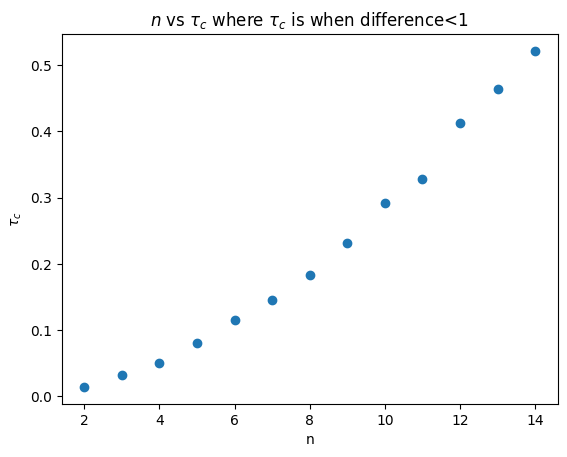

In [13]:
scatter(ns,dat)
xlabel("n")
ylabel(r"$\tau_c$")
title(r"$n$ vs $\tau_c$ where $\tau_c$ is when difference<1")
#plot(ns,ns/30)